# Supervised Learning - Foundations Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \\$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.


### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.


### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [1]:
# Installing the libraries
# uncomment and run the following line if Google Colab is being used
!pip install scikit-learn seaborn matplotlib numpy pandas -q --user

In [2]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [3]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Loading the dataset

In [4]:
#Code to mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [84]:
%cd /content/drive/MyDrive/Python/Project3

/content/drive/MyDrive/Python/Project3


In [88]:
!jupyter nbconvert /content/drive/MyDrive/Python/Project3/JustinSLF_Project3_FullCode.ipynb --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Python/Project3/JustinSLF_Project3_FullCode.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 27 image(s).
[NbConvertApp] Writing 2166629 bytes to /content/drive/MyDrive/Python/Project3/JustinSLF_Project3_FullCode.html


In [5]:
#Code to load data
data = pd.read_csv('/content/drive/MyDrive/Python/Project3/used_device_data.csv')

## Data Overview

In [6]:
#Checking the first few observations of the dataset
data.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [7]:
#Checking the shape of the data
data.shape

(3454, 15)



*   There are 3454 rows and 15 columns



In [8]:
#Checking the data types of the variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

* There are 11 numerical variables (9 are of the float64 datatype and 2 are int64) and 4 categorical (all 4 are object type).
* The dependent/target variable is normalized_used_price which is a float64 datatype.

In [9]:
#Checking the statistical summary of the variables
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand_name,3454,34,Others,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,3454,4,Android,3214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,3454.0,NaN,NaN,NaN,13.713115,3.80528,5.08,12.7,12.83,15.34,30.71
4g,3454,2,yes,2335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5g,3454,2,no,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_camera_mp,3275.0,NaN,NaN,NaN,9.460208,4.815461,0.08,5.0,8.0,13.0,48.0
selfie_camera_mp,3452.0,NaN,NaN,NaN,6.554229,6.970372,0.0,2.0,5.0,8.0,32.0
int_memory,3450.0,NaN,NaN,NaN,54.573099,84.972371,0.01,16.0,32.0,64.0,1024.0
ram,3450.0,NaN,NaN,NaN,4.036122,1.365105,0.02,4.0,4.0,4.0,12.0
battery,3448.0,NaN,NaN,NaN,3133.402697,1299.682844,500.0,2100.0,3000.0,4000.0,9720.0


* There are 34 unique brands and 4 unique OS
* Android is the most frequent OS. 3214/3454 phones in the dataset use Android OS.
* The majority of phones in the dataset are not 5g (3302/3454).
* The mean normalized used price is 4.36 while the mean normalized new price is 5.23.
* The phones range from being released in 2013 to 2020
* The battery ranges from 500 to 9720 with the mean being 3133.40. 50 percent of the batteries are above 3000.
* The mean weight is 182.75, with a low of 69 and a high of 855.
* The average main camera mp is 9.4 while the highest is 48.
* Mean internal memory is 54.57 while the high is 1024.
* Mean RAM is 4 and 50 percent of the phones in the dataset have a RAM of 4.
* Screen size ranges from 5.08 to 30.71, but the average is 13.71.

In [10]:
#Checking for duplicates
data.duplicated().sum()

0

* No duplicated values

In [11]:
#Checking for missing values
data.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


* There are missing values in 6 columns, the majority of them being in main_camera_mp

In [12]:
#Making a copy to preserve original data
df=data.copy()

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of normalized used device prices look like?
2. What percentage of the used device market is dominated by Android devices?
3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?
7. Which attributes are highly correlated with the normalized price of a used device?

### Defining functions for EDA

In [13]:
#Defining function for combined histogram and boxplot
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [14]:
#Defining function for labeled barplot
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

###Univariate Analysis

Question 1: What does the distribution of normalized used device prices look like?

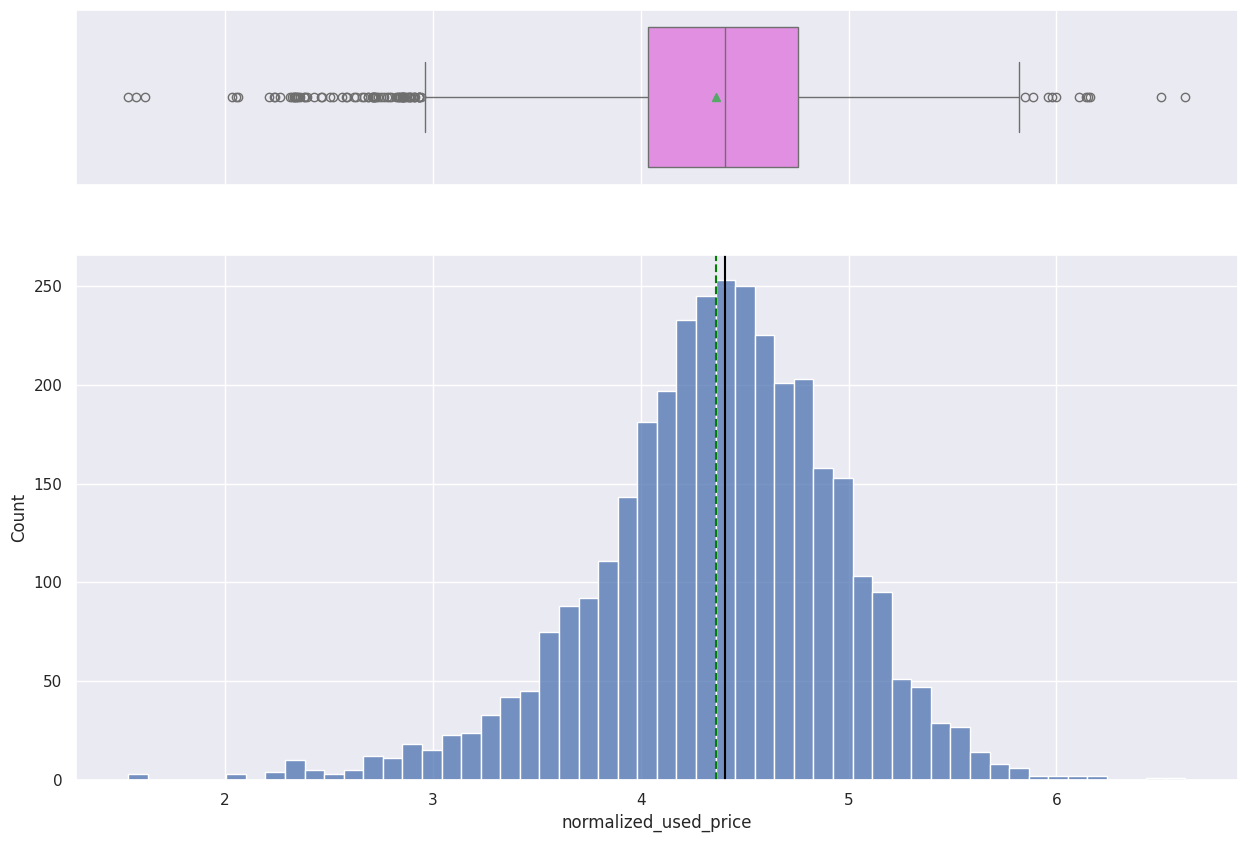

In [15]:
#Code for histogram/barplot of normalized_used_price
histogram_boxplot(df, 'normalized_used_price')

* The distribution has outliers on both sides, but looks fairly normal.
* The mean normalized used device price is 4.36

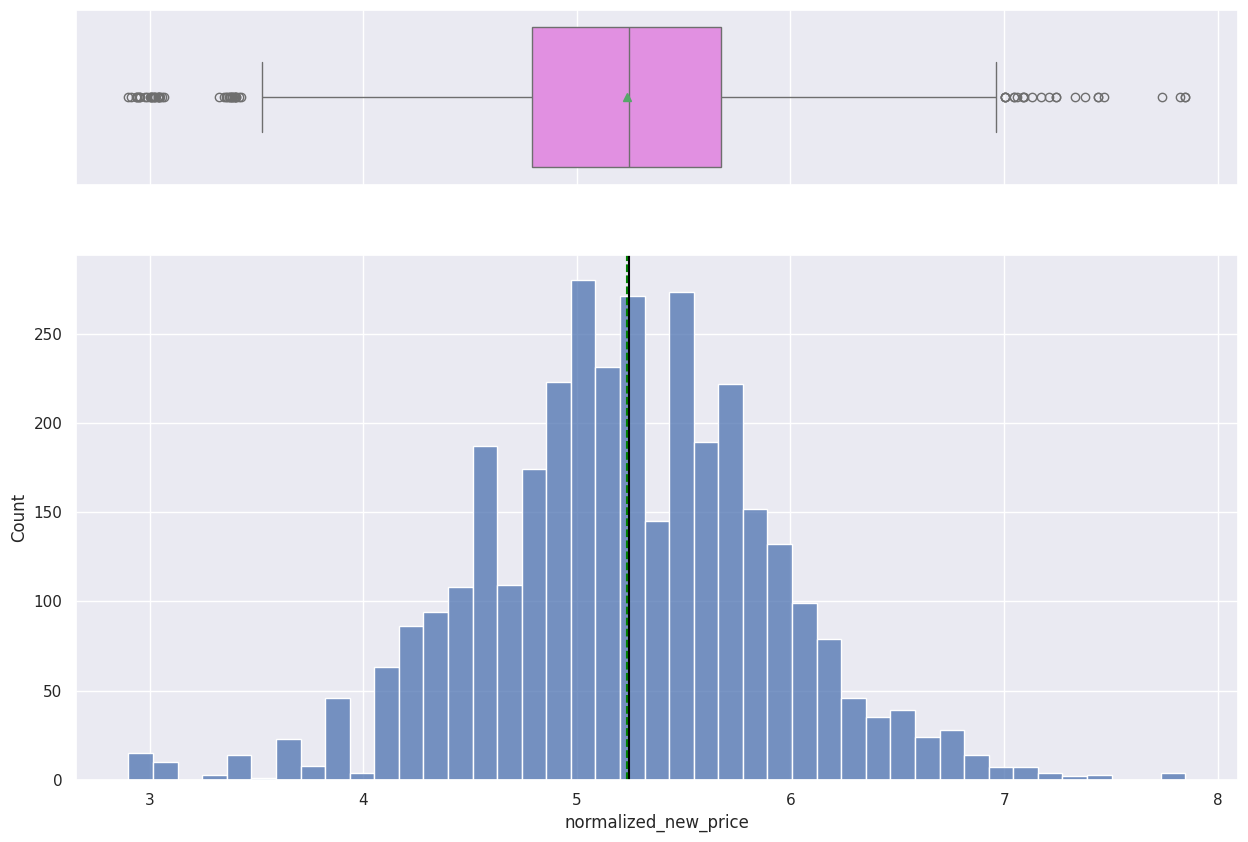

In [16]:
#Code for histogram/barplot of normalized_new_price
histogram_boxplot(df, 'normalized_new_price')

* The distribution for normalized new price looks fairly normal, though there are some outliers on both ends.
* The mean normalized new device price is 5.23

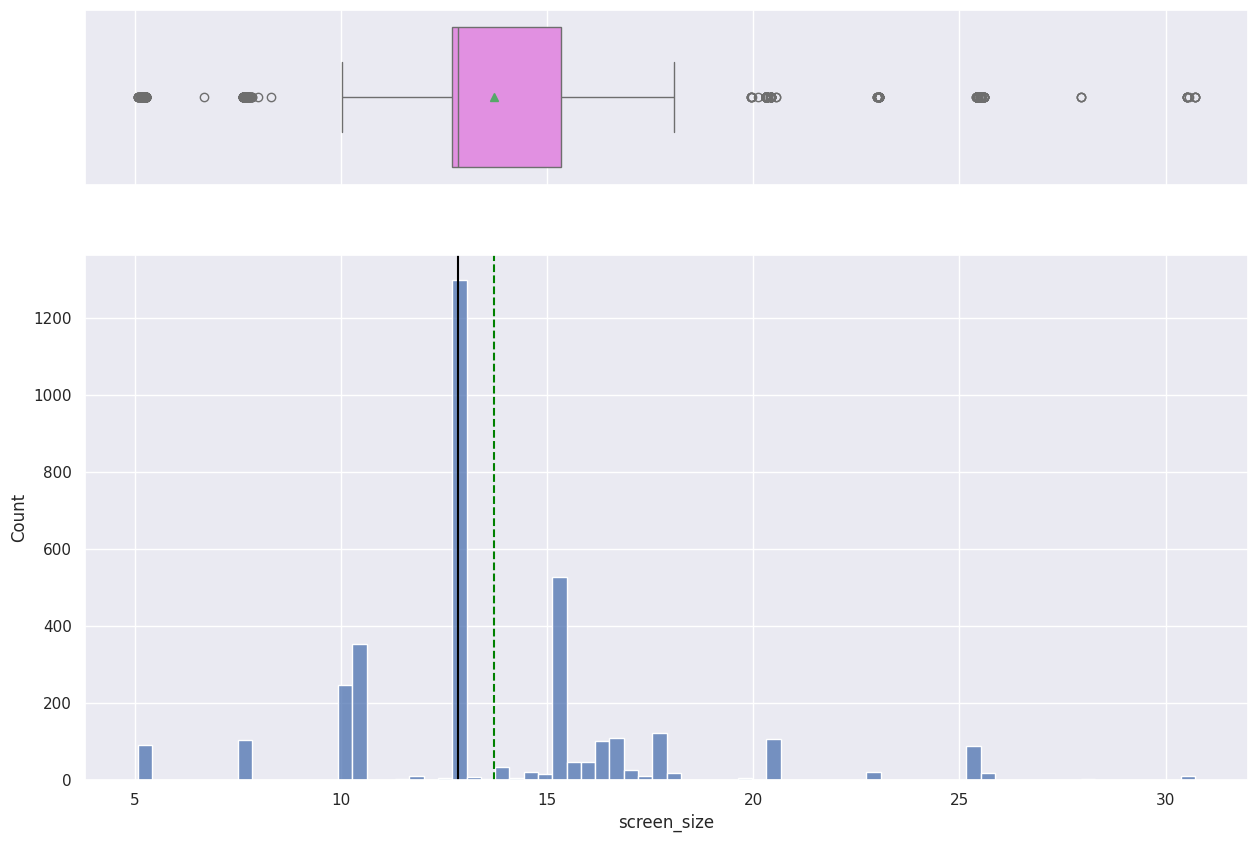

In [17]:
#Code for histogram/barplot of screen_size
histogram_boxplot(df, 'screen_size')

* The average screen size is 13.71 cm.

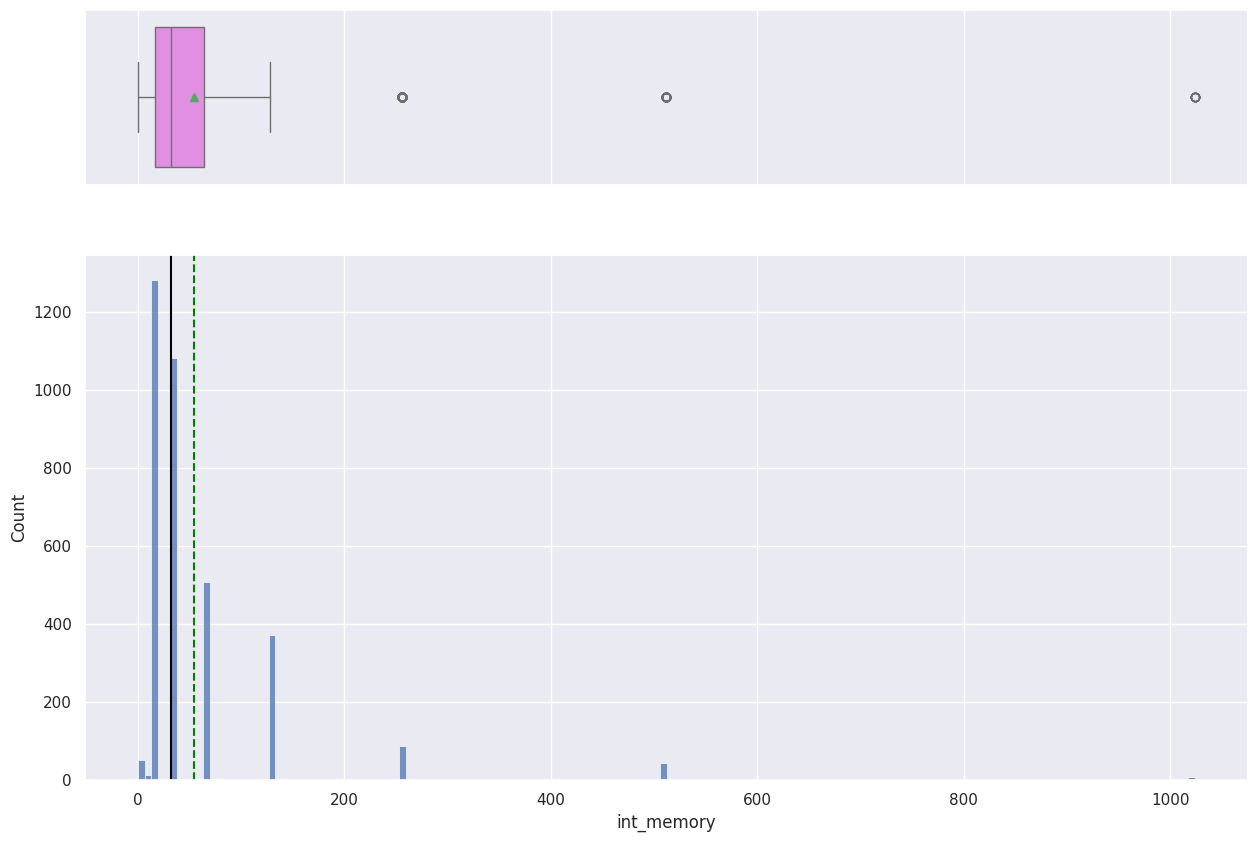

In [18]:
#Code for histogram/barplot of int_memory
histogram_boxplot(df, 'int_memory')

Very right skewed due to the outliers, but the average is around 54 GB for internal memory.

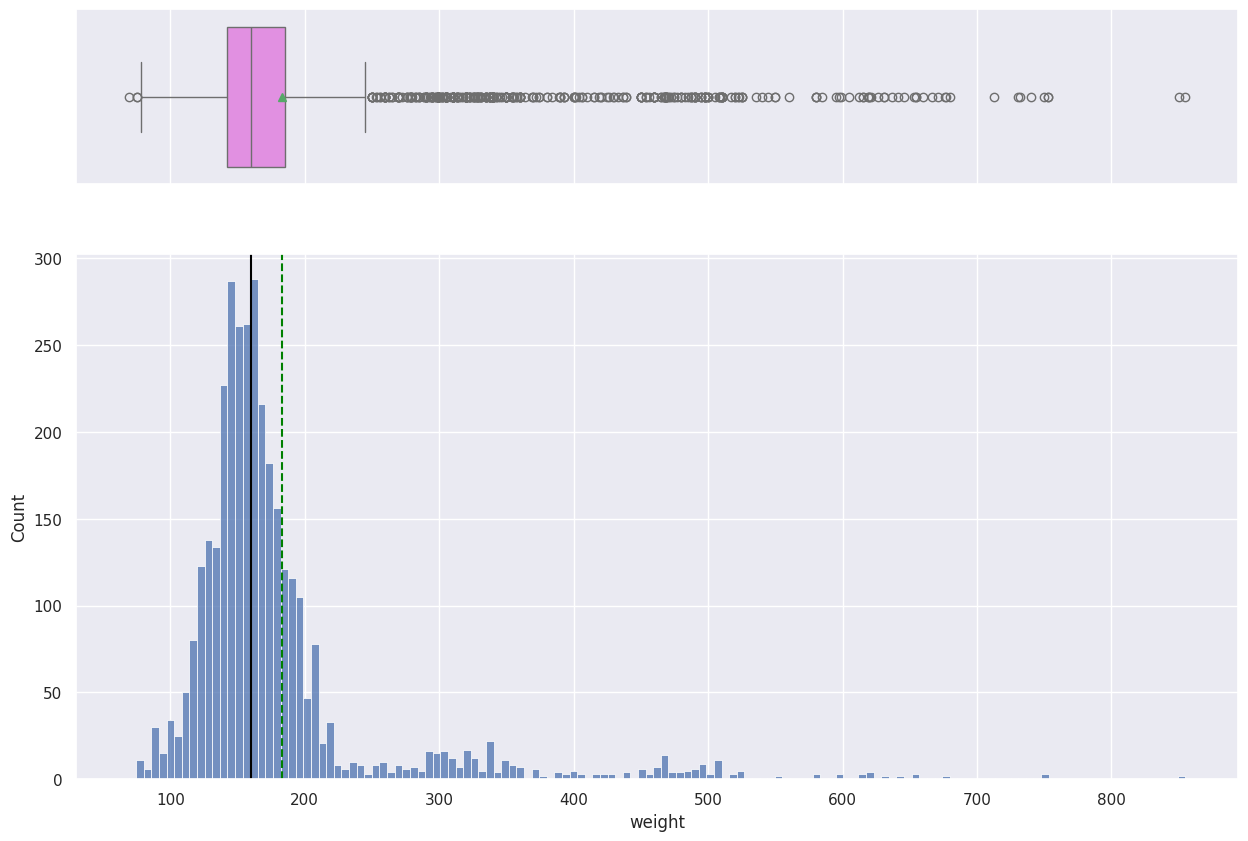

In [19]:
#Code for histogram/barplot of weight
histogram_boxplot(df, 'weight')

* Right skewed distribution with outliers.

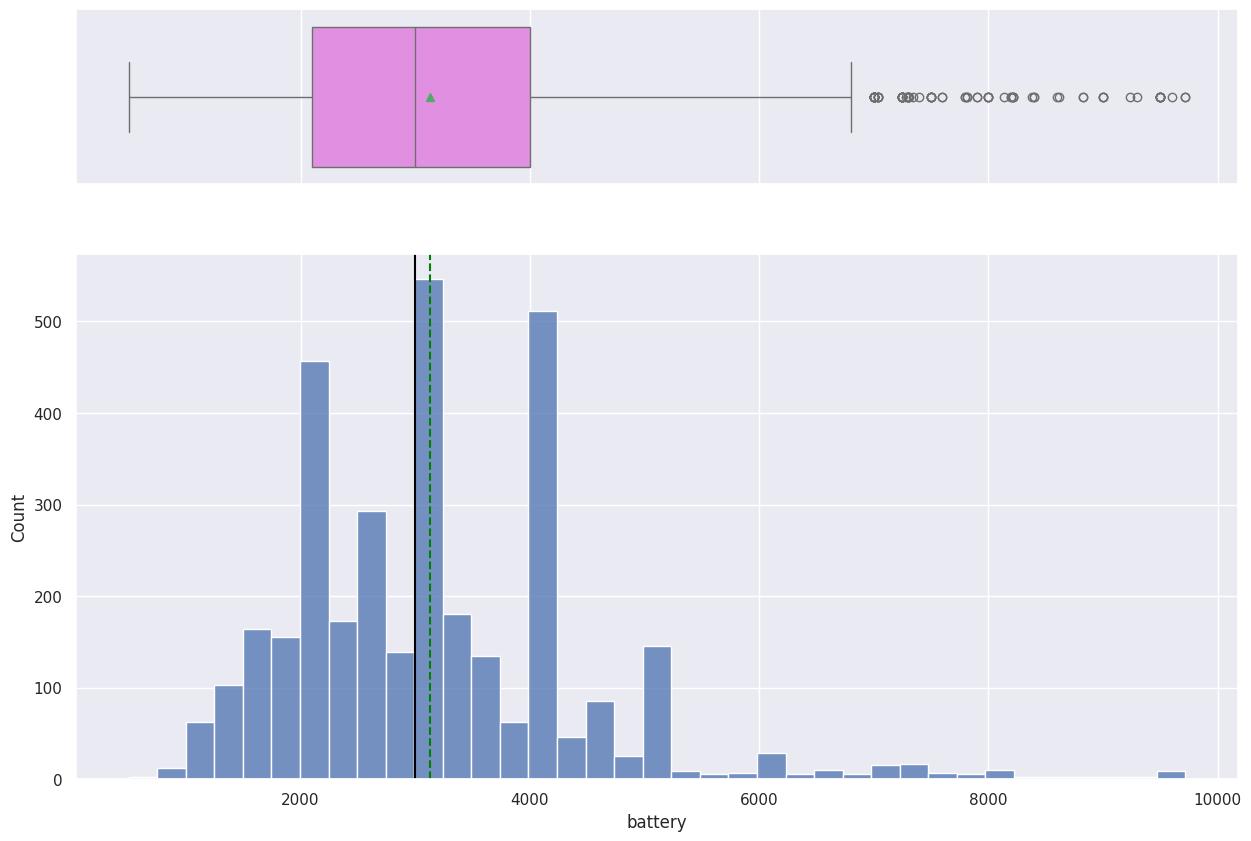

In [20]:
#Code for histogram/barplot of battery
histogram_boxplot(df, 'battery')

* Right skewed with mean of 3000 grams.

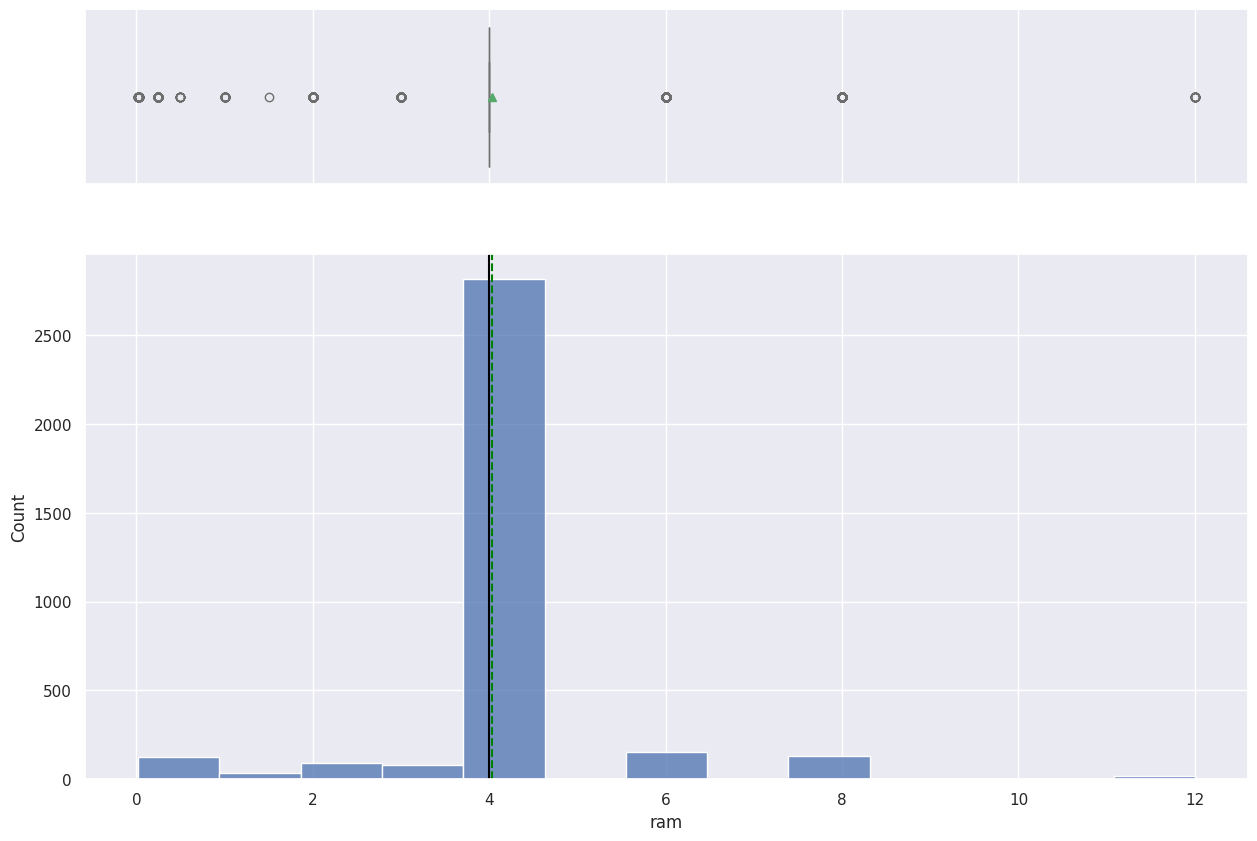

In [21]:
#Code for histogram/barplot of ram
histogram_boxplot(df, 'ram')

* Predominantly focused around the mean of 4GB.


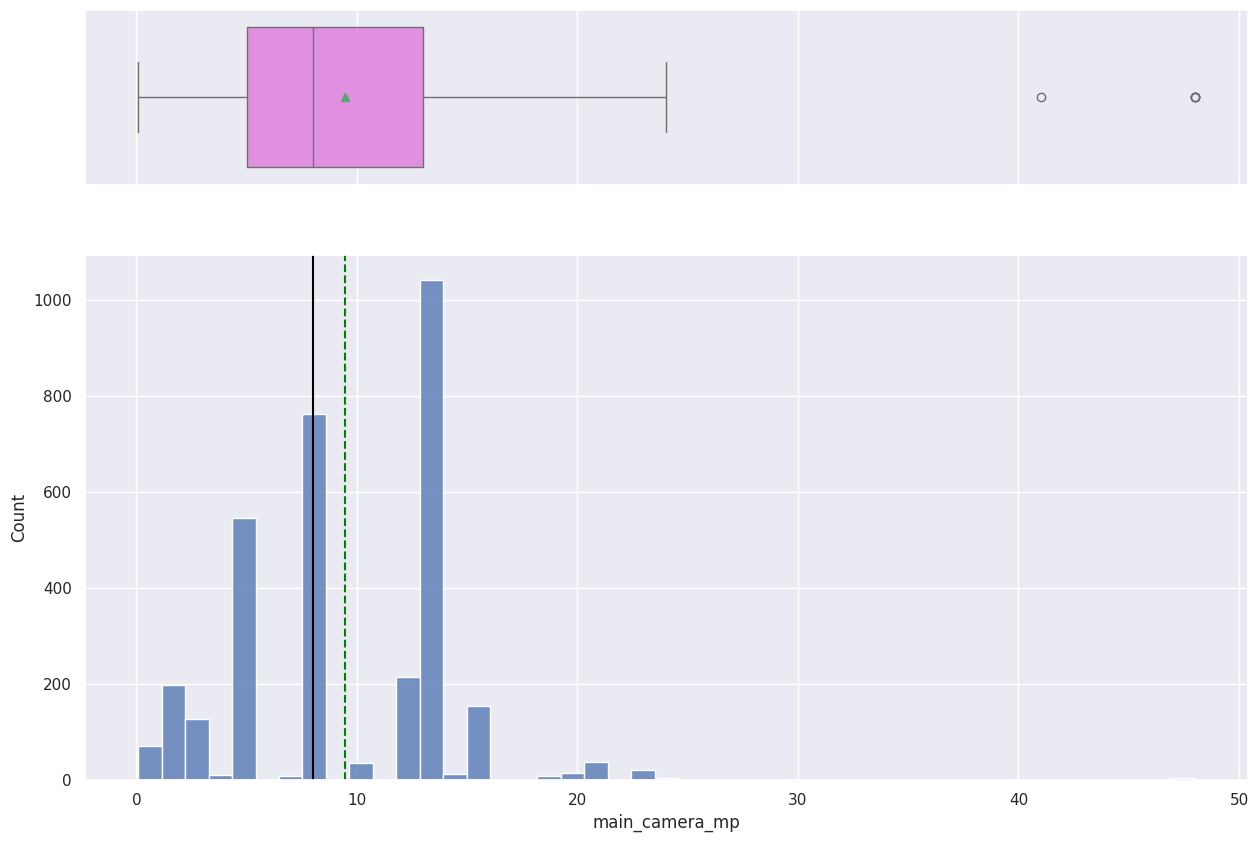

In [22]:
#Code for histogram/barplot of main_camera_mp
histogram_boxplot(df, 'main_camera_mp')

* Somewhat right skewed

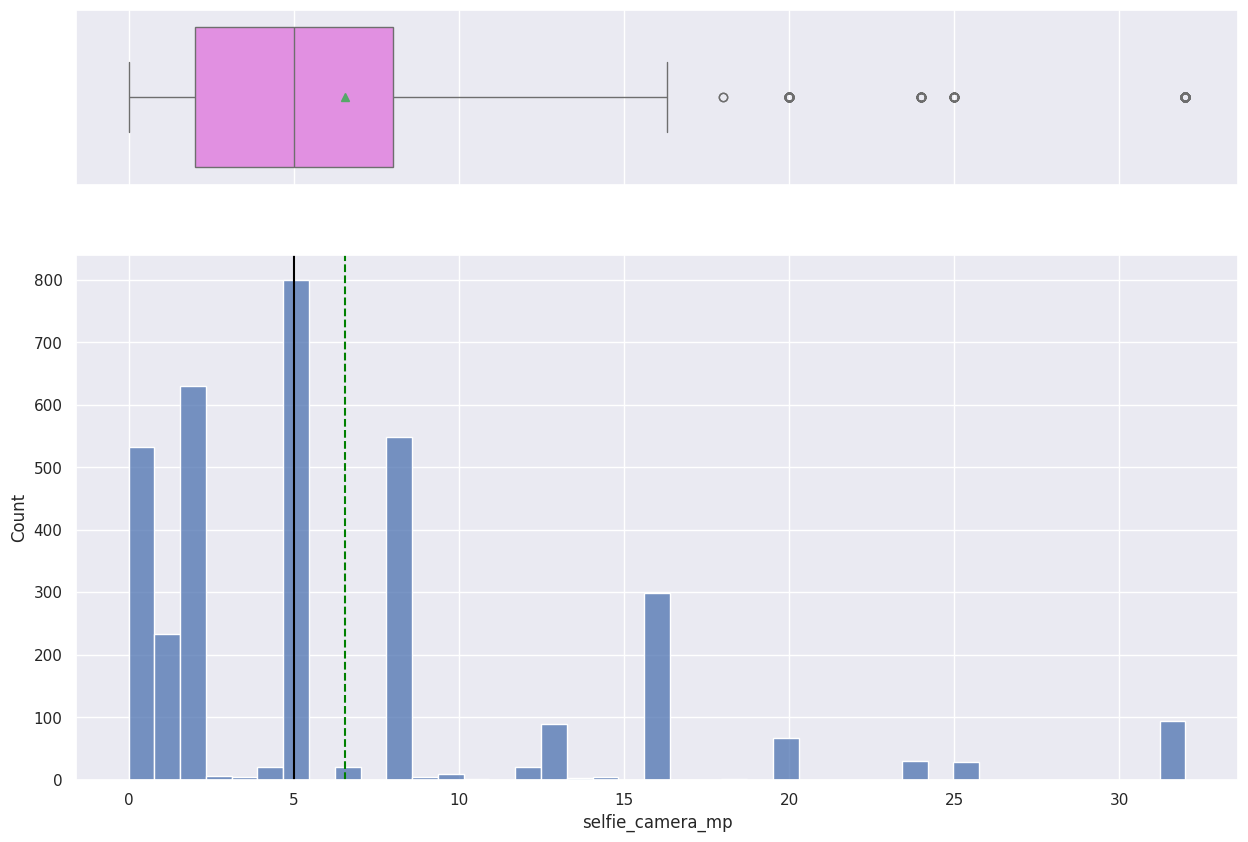

In [23]:
#Code for histogram/barplot of selfie_camera_mp
histogram_boxplot(df, 'selfie_camera_mp')

A bit right skewed.

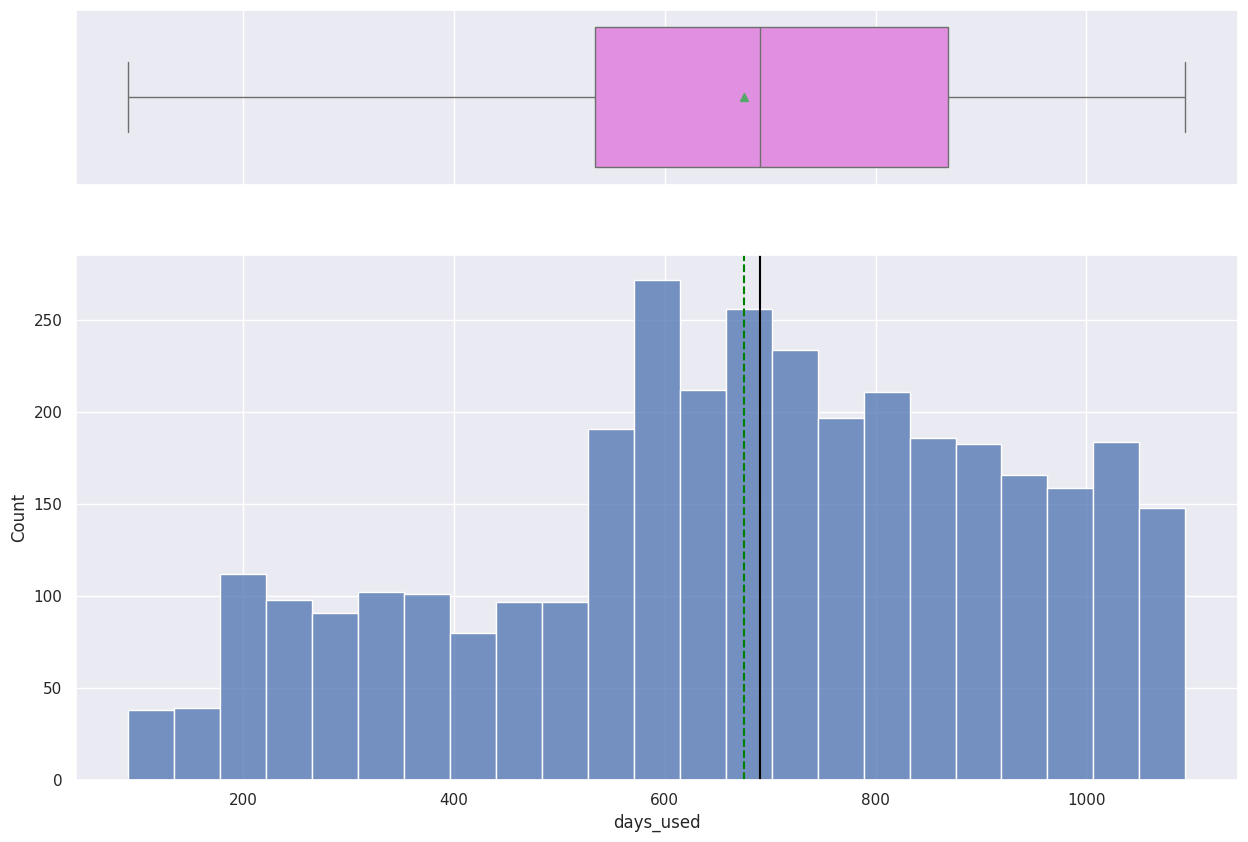

In [24]:
#Code for histogram/barplot of days_used
histogram_boxplot(df, 'days_used')

* Slightly left skewed

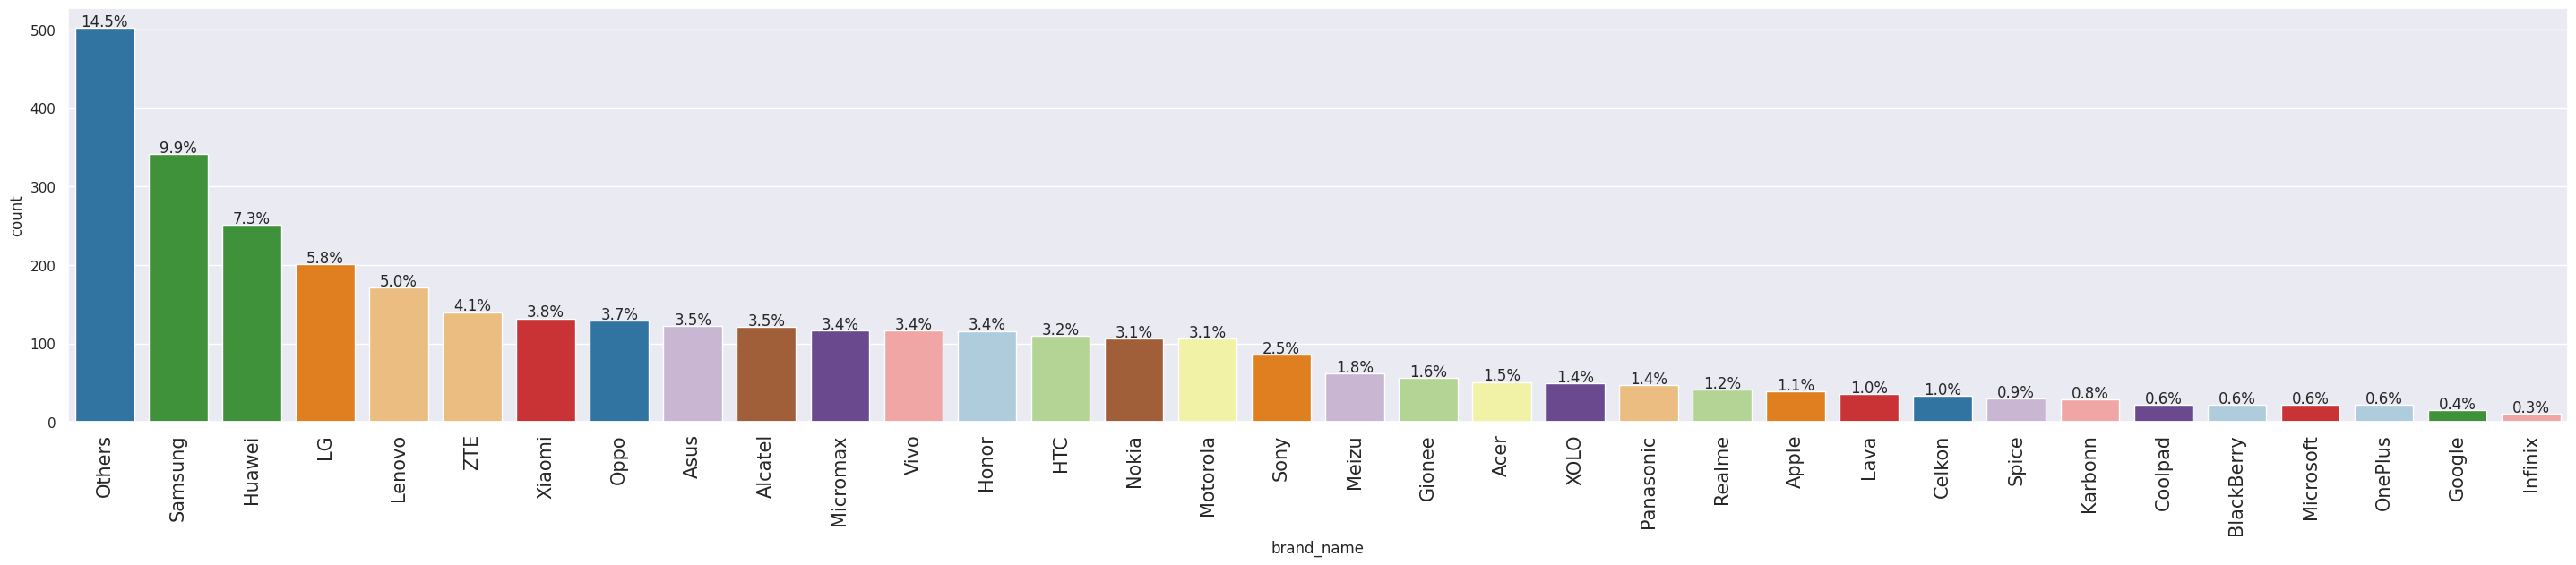

In [25]:
#Code for labeled barplot of brand_name
labeled_barplot(df, 'brand_name', perc=True)

* 14.5 percent of the phones seem to be from Others/non-branded, while the highest prevalent named brand in the dataset is Samsung.

Question 2: What percentage of the used device market is dominated by Android devices?

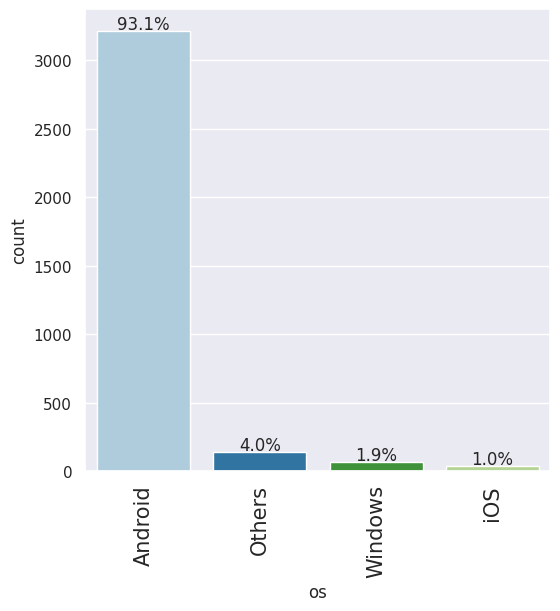

In [26]:
#Code for labeled barplot of os
labeled_barplot(df, 'os', perc=True)

* It appears the 93.1% of the used device market is dominated by Android devices.

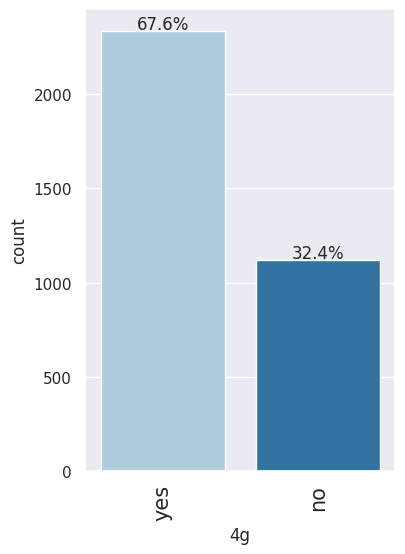

In [27]:
#Code for labeled barplot of 4g
labeled_barplot(df, '4g', perc=True)

* A little over 2/3 of the used phones are 4g.

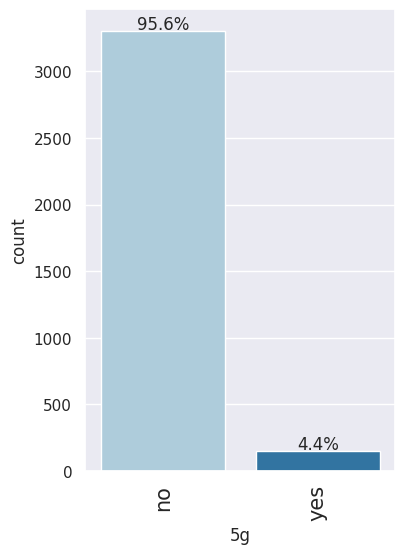

In [28]:
#Code for labeled barplot of 5g
labeled_barplot(df, '5g', perc=True)

* Most of the used phones are not 5g, 95.6% to be exact.

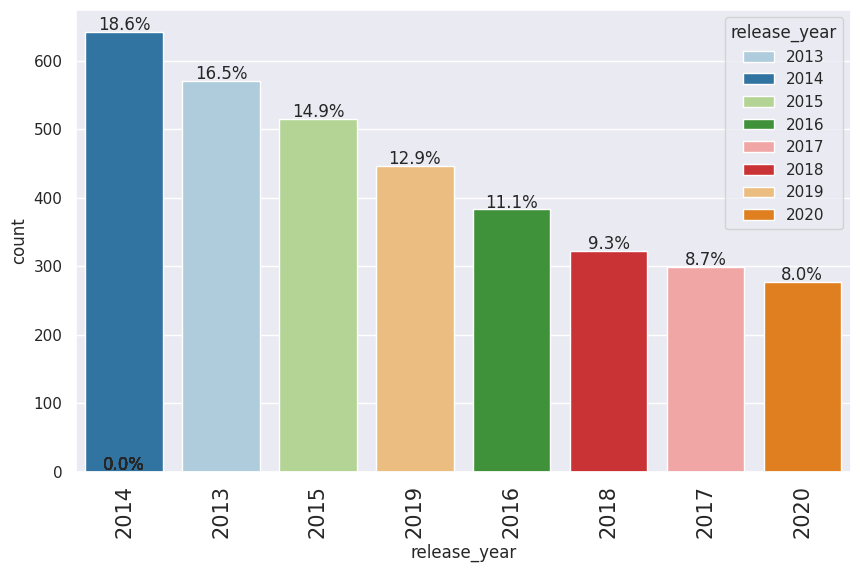

In [29]:
#Code for labeled barplot of release_year
labeled_barplot(df, 'release_year', perc=True)

* 2019 is an interesting observation here. 12.9% of phones are from then which is more than 2016 at 11.1% or 2017 at 8.7%.

###Bivariate Analysis

Question 3: The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?


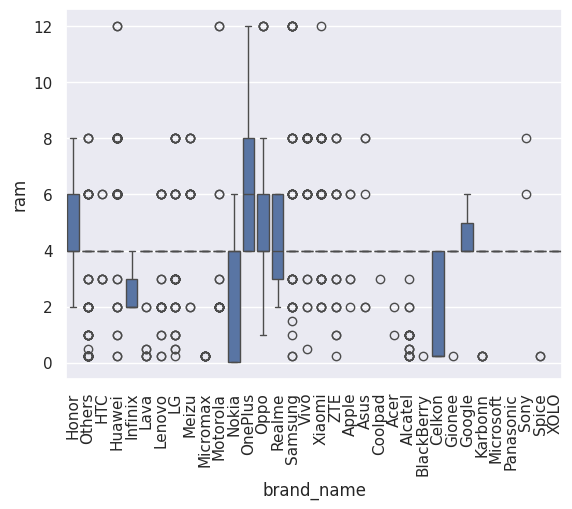

In [30]:
#Code for plot of brand name and ram
sns.boxplot(data=df, x="brand_name", y="ram")
plt.xticks(rotation=90)
plt.show()

* Google, OnePlus, Honor, Realme, and Oppo tends to keep their RAM on the higher side. Though, Oppo and Honor also have phones on the lower end.
* Infinix, Nokia, and Celkon seem to keep theirs on the lower end.

Question 4: A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?


In [31]:
#Code to create dataframe for large battery devices
df_large_battery = df[df.battery > 4500]
df_large_battery.shape

(341, 15)

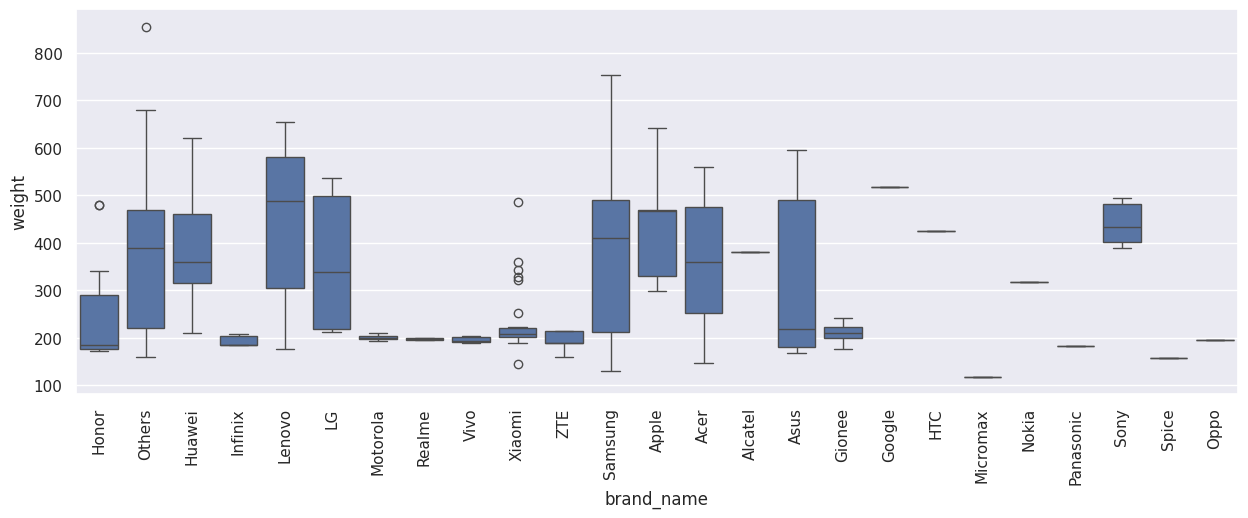

In [32]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=df_large_battery, x="brand_name", y="weight")
plt.xticks(rotation=90)
plt.show()

* Weight for higher capacity batteries does vary quite a bit, especially between brands. Some brands have a larger variety of weights, while others seem clustered around the same weight area.
* Samsung seems to have the widest spread among the named brands.

Question 5: Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?


In [33]:
df_large_screen = df[df.screen_size > (6 * 2.54)] # screen size in cm, so need to convert to inches
df_large_screen.shape

(1099, 15)

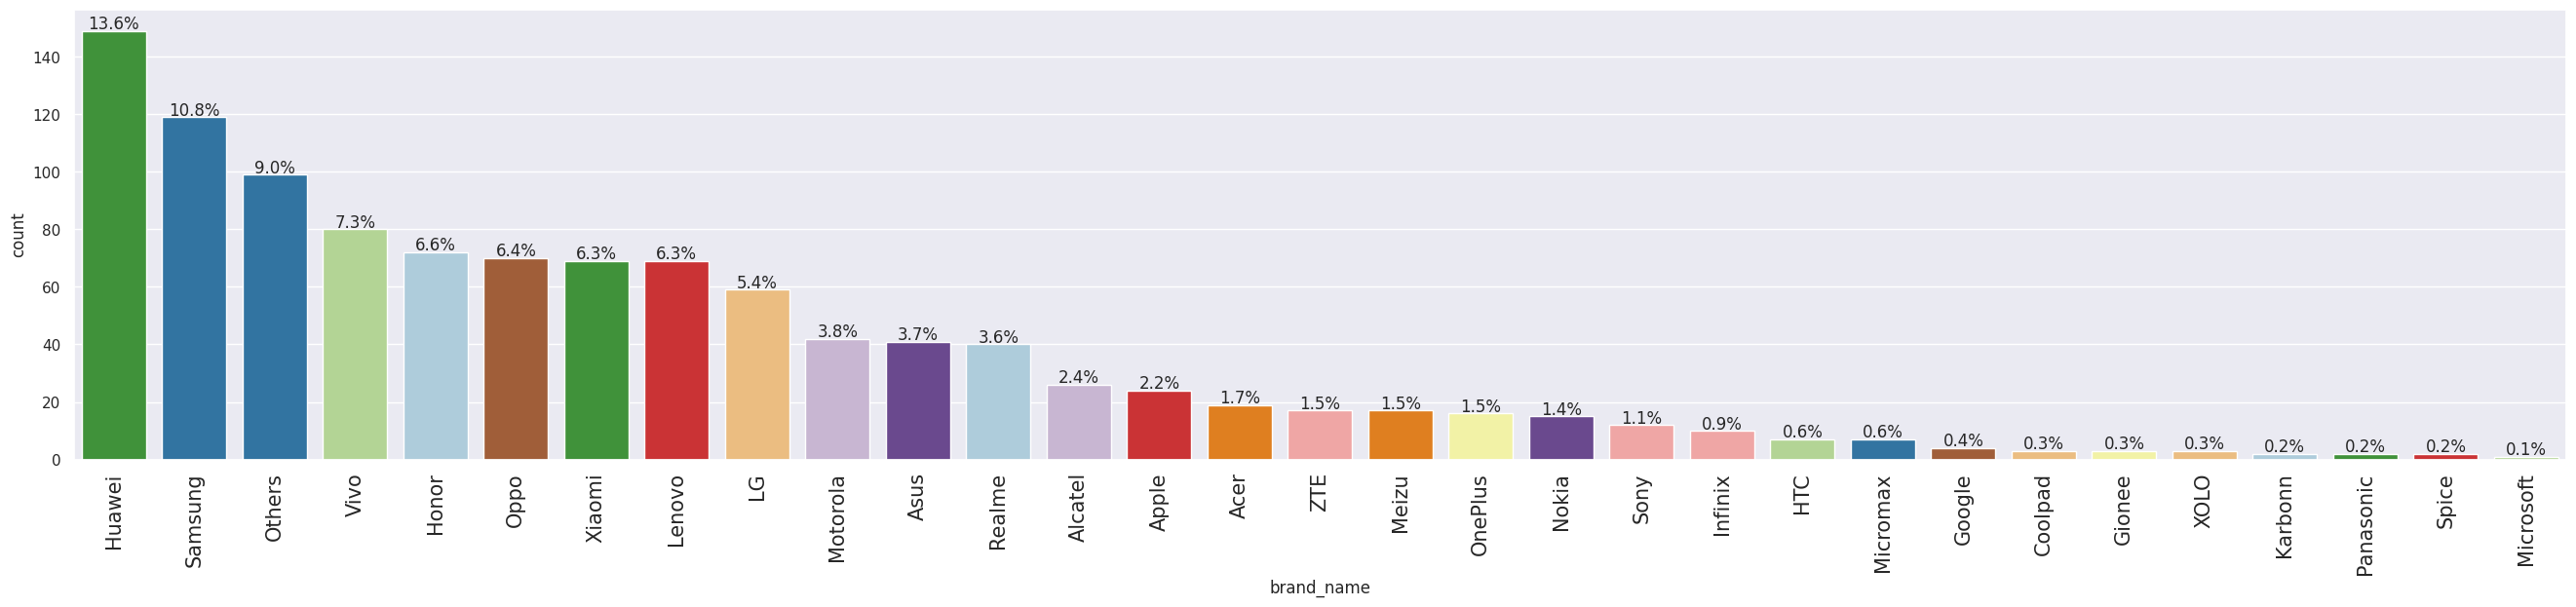

In [34]:
labeled_barplot(df_large_screen, 'brand_name', perc=True)

* There are phones with screen sizes greater than 6 inches available across a number of brands, but Huawei, Samsung, and Others have the most.

Question 6: A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?

In [35]:
df_large_self_camera = df[df.selfie_camera_mp > 8]
df_large_self_camera.shape

(655, 15)

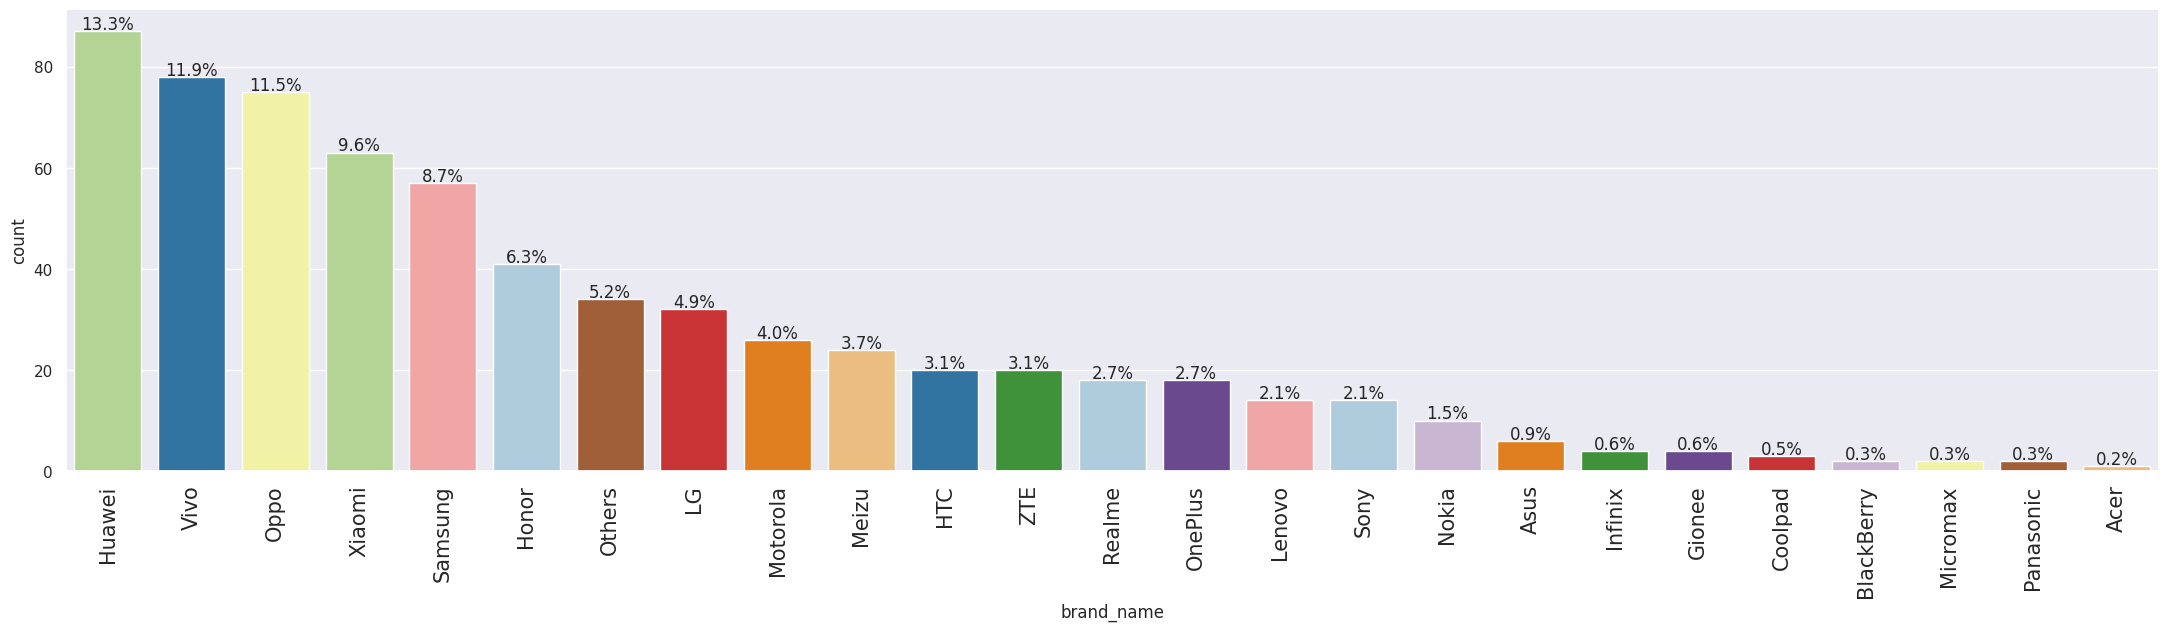

In [36]:
labeled_barplot(df_large_self_camera, 'brand_name', perc=True)

* Huawei, Vivo, Oppo, Xiaomi, and Samsung have the higher percentages in the distribution.

Question 7: Which attributes are highly correlated with the normalized price of a used device?

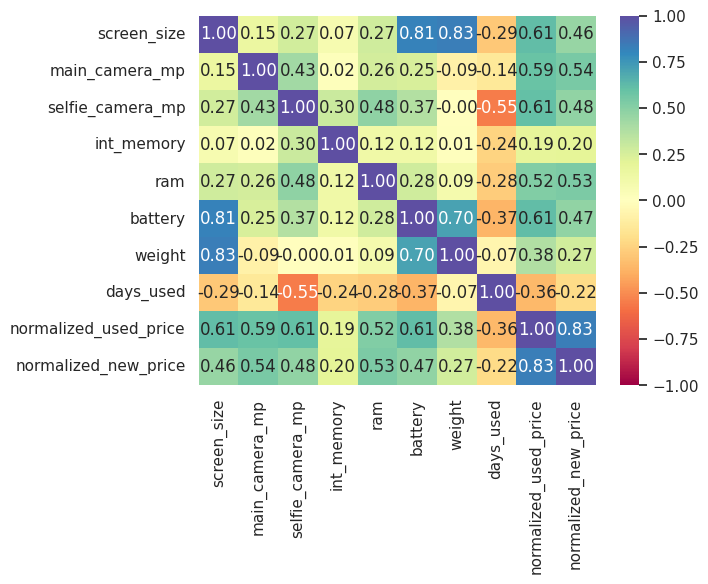

In [37]:
#Code for correlation check
corr_list = df.select_dtypes(include=np.number).columns.tolist()
# dropping release_year as it is a date-related variable
corr_list.remove("release_year")

sns.heatmap(
    df[corr_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

* It looks like normalized new price is the highest correlated with normalized used price.
* Battery, selfie_camera_mp, screen_size, main_camera_mp, and RAM are also moderately to highly correlated with normalized used price.



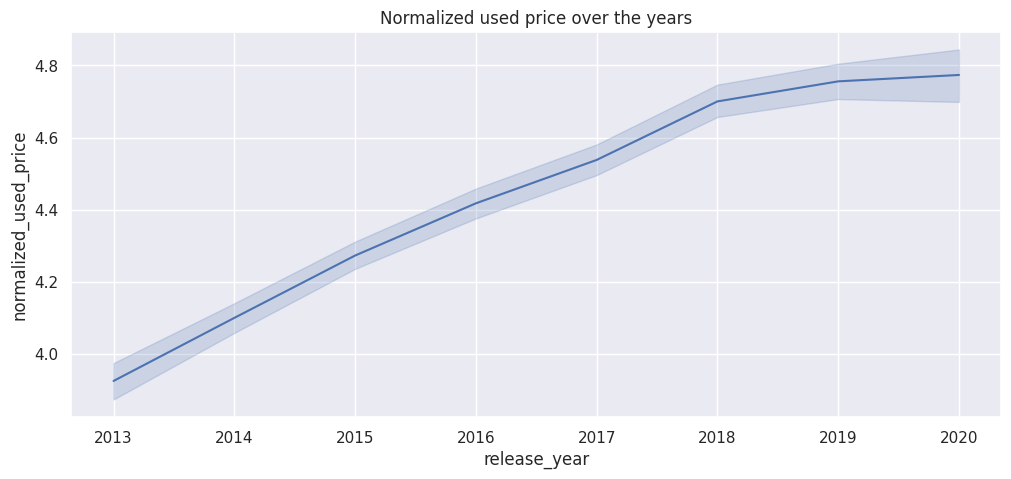

In [38]:
#Code for lineplot of normalized used price and release year
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='release_year', y='normalized_used_price')
plt.title("Normalized used price over the years")
plt.show()

* Normalized used price has gone up over the years.

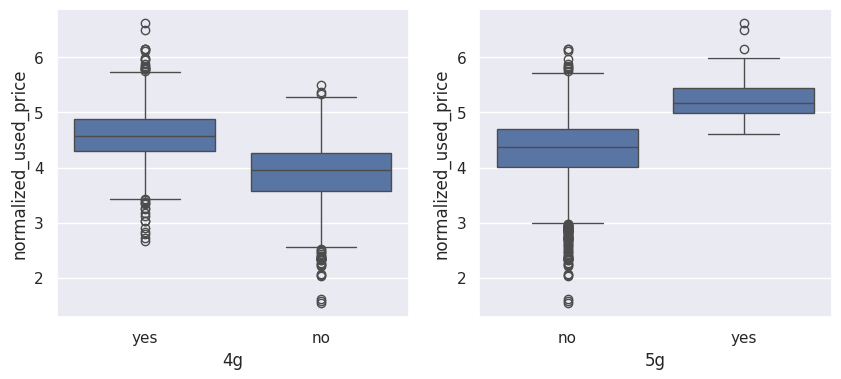

In [39]:
#Code to see 4g and 5g vs normalized price
plt.figure(figsize=(10, 4))

plt.subplot(121)
sns.boxplot(data=df, x="4g", y="normalized_used_price")

plt.subplot(122)
sns.boxplot(data=df, x="5g", y="normalized_used_price")

plt.show()

## Data Preprocessing

###Treating missing values

In [40]:
#Code to make a copy for missing value treatment
df1=df.copy()

In [41]:
#Code to check for missing values
df1.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


* Missing values in 6 columns

In [42]:
#Code to treat missing values by imputing median grouped by release year and brand name
cols_treat = [
    "main_camera_mp",
    "selfie_camera_mp",
    "int_memory",
    "ram",
    "battery",
    "weight",
]

for col in cols_treat:
    df1[col] = df1[col].fillna(
        value=df1.groupby(['release_year', 'brand_name'])[col].transform("median")
    )

In [43]:
#Recheck missing values
df1.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,0
ram,0
battery,6


* So, int_memory and ram seems to be treated, but there are still missing values in 4 columns

In [44]:
#Code to treat remaining missing values by imputing median grouped by brand name
cols_treat = [
    "main_camera_mp",
    "selfie_camera_mp",
    "battery",
    "weight",
]

for col in cols_treat:
    df1[col] = df1[col].fillna(
        value=df1.groupby(['brand_name'])[col].transform("median")
    )

In [45]:
#Code to recheck missing values again
df1.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,10
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


* Now, most of the missing values have been treated and there are only 10 left in main_camera_mp

In [46]:
#Code to treat missing values by median of the column
df1["main_camera_mp"] = df1["main_camera_mp"].fillna(df1["main_camera_mp"].median())

In [47]:
#Code to recheck missing values
df1.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,0
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


* Now all missing values have been treated

###Feature engineering


* Let's create a new column years_from_release from the release_year column with, the year of data collection, 2021, as the baseline.
* We will drop the release_year column.

In [48]:
df1["years_from_release"] = 2021 - df1["release_year"]
df1.drop("release_year", axis=1, inplace=True)
df1["years_from_release"].describe()

,years_from_release
count,3454.000000
mean,5.034742
std,2.298455
min,1.000000
25%,3.000000
50%,5.500000
75%,7.000000
max,8.000000


In [49]:
#Code to check the column was added correctly
df1.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_used_price,normalized_new_price,years_from_release
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.307572,4.715100,1
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.162097,5.519018,1
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.111084,5.884631,1
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.135387,5.630961,1
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.389995,4.947837,1


###Outlier detection and treatment


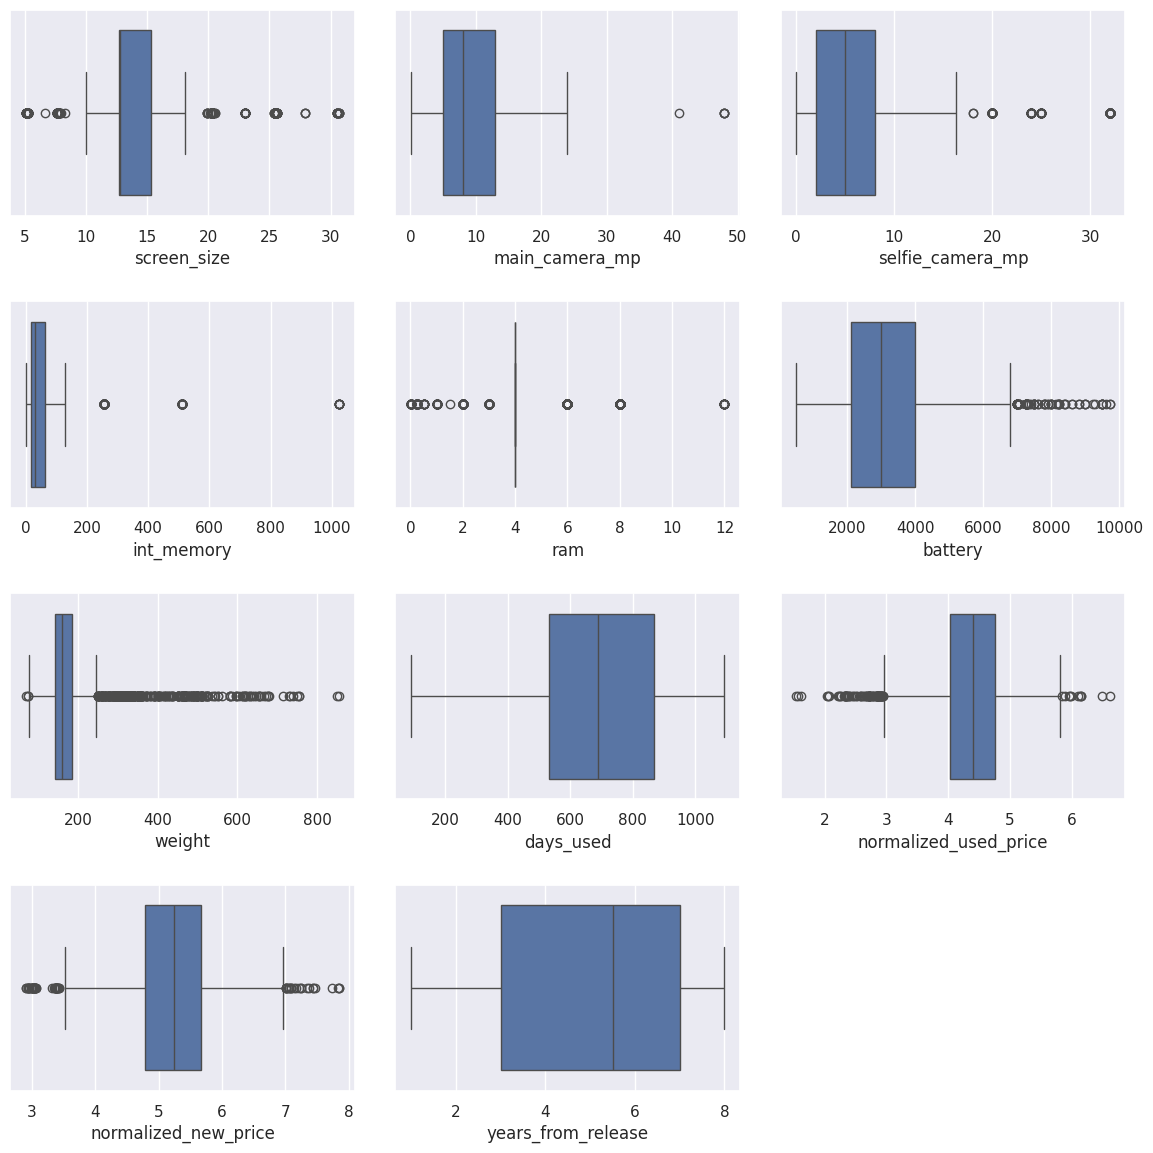

In [50]:
# outlier detection using boxplot
num_cols = df1.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12, 12))

for i, variable in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(data=df1, x=variable)
    plt.tight_layout(pad=2)

plt.show()

* There are a lot of outliers in the data, but we will not be treating them as they are valid observations.

###Preparing data for modeling

* We want to predict the normalized price of used devices
* Before building a model, need to to encode categorical features
* Then, split the data into train and test to be able to evaluate the model that we build on the train data

In [51]:
#Code to define X and Y variables
X = df1.drop(["normalized_used_price"], axis=1)
y = df1["normalized_used_price"]

print(X.head())
print(y.head())

  brand_name       os  screen_size   4g   5g  main_camera_mp  \
0      Honor  Android        14.50  yes   no            13.0   
1      Honor  Android        17.30  yes  yes            13.0   
2      Honor  Android        16.69  yes  yes            13.0   
3      Honor  Android        25.50  yes  yes            13.0   
4      Honor  Android        15.32  yes   no            13.0   

   selfie_camera_mp  int_memory  ram  battery  weight  days_used  \
0               5.0        64.0  3.0   3020.0   146.0        127   
1              16.0       128.0  8.0   4300.0   213.0        325   
2               8.0       128.0  8.0   4200.0   213.0        162   
3               8.0        64.0  6.0   7250.0   480.0        345   
4               8.0        64.0  3.0   5000.0   185.0        293   

   normalized_new_price  years_from_release  
0              4.715100                   1  
1              5.519018                   1  
2              5.884631                   1  
3              5.63096

In [52]:
#Code to add the intercept to data
X = sm.add_constant(X)

In [53]:
#Code to create dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True
)
X.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.715100,...,False,False,False,False,False,False,False,False,True,False
1,1.0,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.519018,...,False,False,False,False,False,False,False,False,True,True
2,1.0,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.884631,...,False,False,False,False,False,False,False,False,True,True
3,1.0,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.630961,...,False,False,False,False,False,False,False,False,True,True
4,1.0,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.947837,...,False,False,False,False,False,False,False,False,True,False


In [54]:
#Code to convert the input attributes into float type for modeling
X = X.astype(float)
X.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127.0,4.715100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325.0,5.519018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,1.0,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162.0,5.884631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,1.0,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345.0,5.630961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293.0,4.947837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [55]:
#Code to split the data in 70:30 ratio for train to test data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [56]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 2417
Number of rows in test data = 1037


## EDA Revist

* We manipulated some of the data, so let's check where it was most changed.

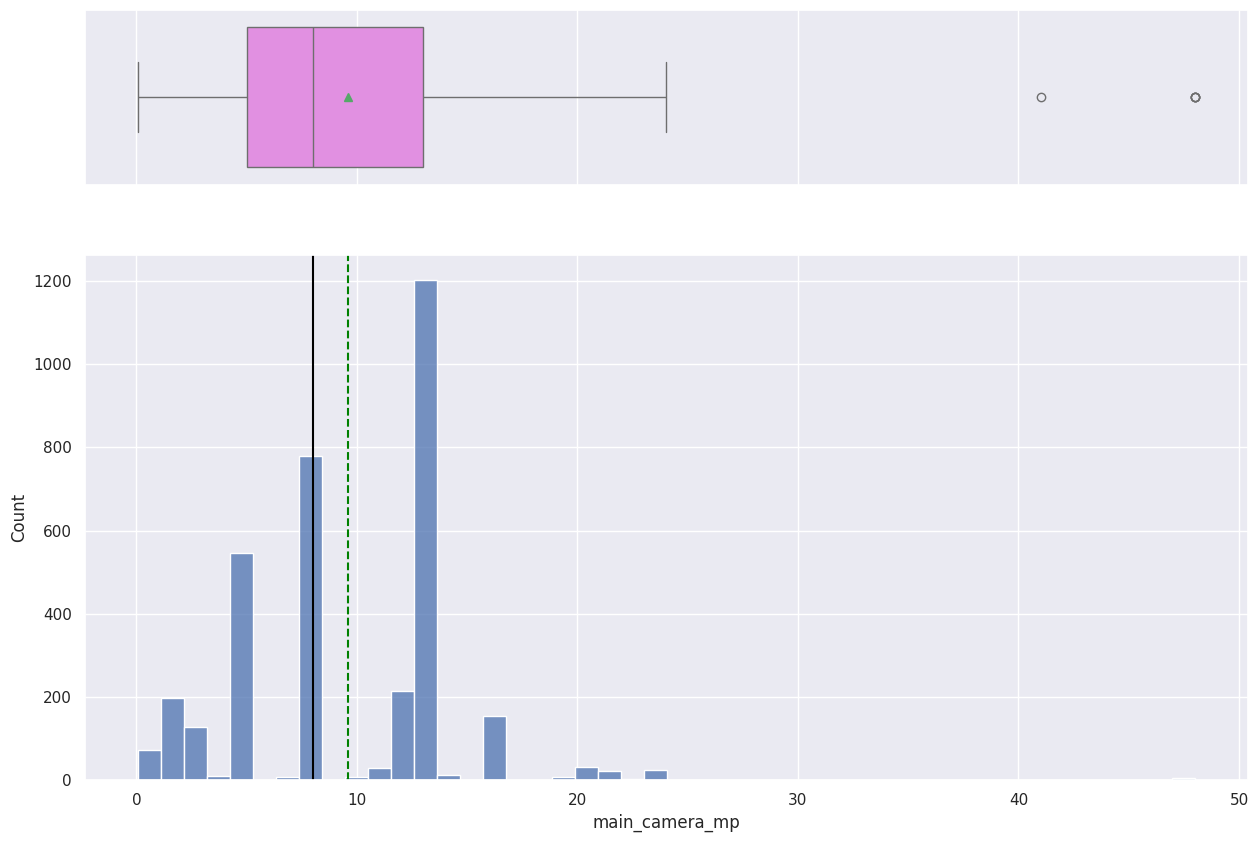

In [57]:
histogram_boxplot(df1, "main_camera_mp")

* Looks about the same as previously.

## Model Building - Linear Regression

In [58]:
olsmodel1 = sm.OLS(y_train, x_train).fit()
print(olsmodel1.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     268.7
Date:                   Sat, 25 Jan 2025   Prob (F-statistic):               0.00
Time:                           06:03:05   Log-Likelihood:                 123.85
No. Observations:                   2417   AIC:                            -149.7
Df Residuals:                       2368   BIC:                             134.0
Df Model:                             48                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


## Model Performance Check

* Checking the performance of the model using different metrics.
  * We will be using metric functions defined in sklearn for RMSE, MAE, and R-squared.
  * We will define a function to calculate MAPE and adjusted R-squared.
  * We will create a function which will print out all the above metrics in one go.

In [59]:
#Code for defining function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


#Code for defining function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# Code for defining function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [60]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel1_train_perf = model_performance_regression(olsmodel1, x_train, y_train)
olsmodel1_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.229884,0.180326,0.844886,0.841675,4.326841


In [61]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel1_test_perf = model_performance_regression(olsmodel1, x_test, y_test)
olsmodel1_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.238358,0.184749,0.842479,0.834659,4.501651


* The training R-squared is 0.84, so the model isn't underfitting.
* The training and test RMSE and MAE are both comparable, so it suggests that it isn't overfitting either.
* MAE suggests that the model can predict used device prices within a mean error of 0.18 on the test data
* MAPE of 4.5 on the test data means we're able to predict within 4.5% of the used device prices

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied. So, need to check the following Linear Regression assumptions:

  * No Multicollinearity

  * Linearity of variables

  *  Independence of error terms

  * Normality of error terms

  * No Heteroscedasticity

### Test for Multicollinearity


* We will test for multicollinearity using VIF.

In [62]:
#Code to define function to get VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor


def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [63]:
checking_vif(x_train)

,feature,VIF
0,const,227.744081
1,screen_size,7.677290
2,main_camera_mp,2.285051
3,selfie_camera_mp,2.812473
4,int_memory,1.364152
5,ram,2.282352
6,battery,4.081780
7,weight,6.396749
8,days_used,2.660269
9,normalized_new_price,3.119430


* There appear to be multiple columns with a VIF > 5, which suggests multicollinearity, after ignoring the dummy variables and the constant
* So, we will systematically drop numerical columns that have VIF>5

In [64]:
#Code to define function to treat multicollinearity
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp


In [65]:
suspect_list = ["screen_size", "weight"]

res = treating_multicollinearity(x_train, y_train, suspect_list)
res

,col,Adj. R-squared after_dropping col,RMSE after dropping col
0,screen_size,0.838381,0.234703
1,weight,0.838071,0.234928


In [66]:
col_to_drop = "weight"
x_train2 = x_train.loc[:, ~x_train.columns.str.startswith(col_to_drop)]
x_test2 = x_test.loc[:, ~x_test.columns.str.startswith(col_to_drop)]

# Check VIF now
vif = checking_vif(x_train2)
print("VIF after dropping ", col_to_drop)
vif

VIF after dropping  weight


,feature,VIF
0,const,208.983030
1,screen_size,3.593184
2,main_camera_mp,2.188817
3,selfie_camera_mp,2.787946
4,int_memory,1.364018
5,ram,2.280390
6,battery,3.681135
7,days_used,2.648280
8,normalized_new_price,3.116297
9,years_from_release,4.726722


* Now the multicollinearity has been handled, so we can rebuild and check the updated model.
* Also, will look at the p-values of predictor variables to check their significance.

In [67]:
olsmodel2 = sm.OLS(y_train, x_train2).fit()
print(olsmodel2.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.841
Model:                               OLS   Adj. R-squared:                  0.838
Method:                    Least Squares   F-statistic:                     267.0
Date:                   Sat, 25 Jan 2025   Prob (F-statistic):               0.00
Time:                           06:03:08   Log-Likelihood:                 95.629
No. Observations:                   2417   AIC:                            -95.26
Df Residuals:                       2369   BIC:                             182.7
Df Model:                             47                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


* The adjusted R-squared dropped to 0.838 from 0.842, so the dropped column likely didn't have much impact on the model.

### Dealing with high p-value variables

In [68]:
# initial list of columns
predictors = x_train2.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'screen_size', 'main_camera_mp', 'selfie_camera_mp', 'ram', 'days_used', 'normalized_new_price', 'years_from_release', 'brand_name_Lenovo', 'brand_name_Nokia', 'brand_name_Xiaomi', '4g_yes']


In [69]:
x_train3 = x_train2[selected_features]
x_test3 = x_test2[selected_features]

In [70]:
olsmodel3 = sm.OLS(y_train, x_train3).fit()
print(olsmodel3.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.839
Model:                               OLS   Adj. R-squared:                  0.839
Method:                    Least Squares   F-statistic:                     1142.
Date:                   Sat, 25 Jan 2025   Prob (F-statistic):               0.00
Time:                           06:03:09   Log-Likelihood:                 81.071
No. Observations:                   2417   AIC:                            -138.1
Df Residuals:                       2405   BIC:                            -68.66
Df Model:                             11                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [71]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel3_train_perf = model_performance_regression(olsmodel3, x_train3, y_train)
olsmodel3_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.233989,0.183177,0.839296,0.838494,4.392265


In [72]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel3_test_perf = model_performance_regression(olsmodel3, x_test3, y_test)
olsmodel3_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.238554,0.185,0.84222,0.840371,4.500963


* Now no feature has p-value greater than 0.05, so we'll take the features in x_train3 as the final set of predictor variables and olsmodel3 as the final model to move forward with.
* Now adjusted R-squared is 0.839, i.e., our model is able to explain ~84% of the variance
* The adjusted R-squared in olsmodel1 (where we considered the variables without multicollinearity) was 0.842 which shows that the variables we dropped were not affecting the model much
* RMSE and MAE values are comparable for training and test sets, indicating that the model is not overfitting

### Test for Linearity & Independence


* We will test for linearity and independence by making a plot of fitted values vs residuals and checking for patterns.
  * If there is no pattern, then we say the model is linear and residuals are independent. Otherwise, the model is showing signs of non-linearity and residuals are not independent.

In [73]:
# let us create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsmodel3.fittedvalues  # predicted values
df_pred["Residuals"] = olsmodel3.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
3026,4.087488,3.858599,0.228888
1525,4.448399,4.613833,-0.165434
1128,4.315353,4.277568,0.037785
3003,4.282068,4.252225,0.029844
2907,4.456438,4.440283,0.016156


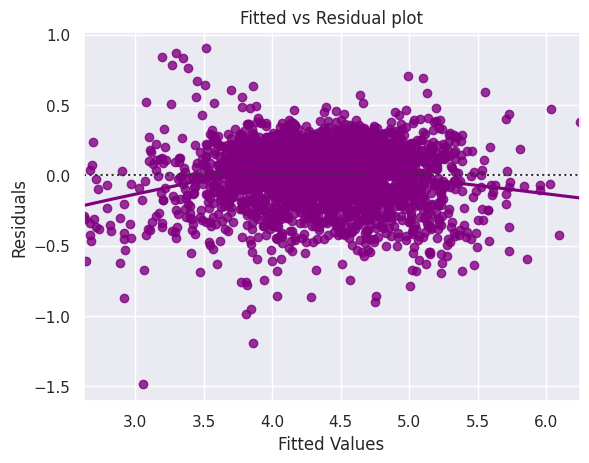

In [74]:
# let's plot the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

* There isn't an obvious pattern in the plot above, so we can say the assumptions for linearity and independence are satisfied

### Test for Normality


* We will test for normality by checking the distribution of residuals, by checking the Q-Q plot of residuals, and by using the Shapiro-Wilk test.
  * If the residuals follow a normal distribution, they will make a straight line plot, otherwise not.
  * If the p-value of the Shapiro-Wilk test is greater than 0.05, we can say the residuals are normally distributed.

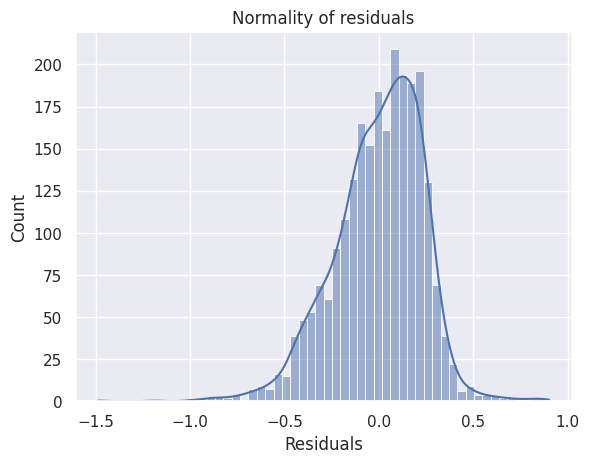

In [75]:
sns.histplot(data=df_pred, x="Residuals", kde=True)
plt.title("Normality of residuals")
plt.show()

* The histogram of residuals does have a bell-like shape.
* Let's check the Q-Q plot.

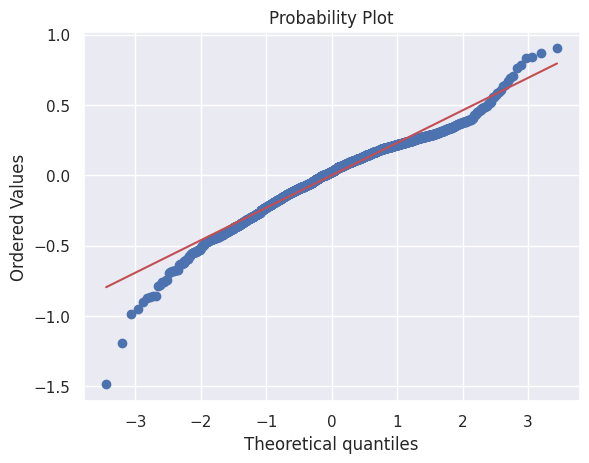

In [76]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

* The residuals more or less follow a straight line except for the tails, especially on the upper right tail
* Let's check the results of the Shapiro-Wilk test.

In [77]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=0.9724019647308455, pvalue=3.462926954252782e-21)

* Since p-value < 0.05, the residuals are not normal as per the Shapiro-Wilk test.
* Strictly speaking, the residuals are not normal. However, as an approximation, we can accept this distribution as close to being normal. So, the assumption is satisfied.

### Test for Homoscedasticity

* We will test for homoscedasticity by using the goldfeldquandt test.
  * If we get a p-value greater than 0.05, we can say that the residuals are homoscedastic. Otherwise, they are heteroscedastic.

In [78]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train3)
lzip(name, test)

[('F statistic', 1.0554902509992026), ('p-value', 0.1752049183299785)]

* Since p-value > 0.05, we can say that the residuals are homoscedastic. So, this assumption is satisfied.

### Prediction Check

In [79]:
# predictions on the test set
pred = olsmodel3.predict(x_test3)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
1995,4.566741,4.370046
2341,3.696103,3.954403
1913,3.592093,3.760742
688,4.306495,4.099280
650,4.522115,5.117977
2291,4.259294,4.392088
40,4.997685,5.404365
1884,3.875359,4.103732
2538,4.206631,4.044604
45,5.380450,5.301336


* We can see that our model has returned pretty decent prediction results and the actual/predicted values are comparable.

## Final Model

In [80]:
olsmodel_final = sm.OLS(y_train, x_train3).fit()
print(olsmodel_final.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.839
Model:                               OLS   Adj. R-squared:                  0.839
Method:                    Least Squares   F-statistic:                     1142.
Date:                   Sat, 25 Jan 2025   Prob (F-statistic):               0.00
Time:                           06:03:10   Log-Likelihood:                 81.071
No. Observations:                   2417   AIC:                            -138.1
Df Residuals:                       2405   BIC:                            -68.66
Df Model:                             11                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [81]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(
    olsmodel_final, x_train3, y_train
)
olsmodel_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.233989,0.183177,0.839296,0.838494,4.392265


In [82]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_final_test_perf = model_performance_regression(
    olsmodel_final, x_test3, y_test
)
olsmodel_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.238554,0.185,0.84222,0.840371,4.500963


* The model is able to explain ~84% of the variation in the data
* The train and test RMSE and MAE are low and comparable. Therefore, our model is not suffering from overfitting. Nor underfitting because R-squared is 0.839.
* The MAPE on the test set suggests we can predict within 4.5% of the normalized used price
* MAE suggests that the model can predict normalized used price within a mean error of 0.185 on the test data
* As such, we can conclude the model olsmodel_final is good for prediction as well as inference purposes.

## Actionable Insights and Recommendations

* The model is able to explain ~84% of the variation in the data and within 4.5% of the normalized used price on the test data, which is good. This indicates that the model is good for prediction as well as inference purposes.
* If the normalized new price of a device increases by one unit, then its normalized used price increases by 0.4282 units, all other variables held constant
* If the screen size of a device increases by one unit, then its normalized used price increases by 0.0433 units, all other variables held constant
* If the main_camera_mp of a device increases by one unit, then its normalized used price increases by 0.0189 units, all other variables held constant
* If the selfie_camera_mp of a device increases by one unit, then its normalized used price increases by 0.0131 units, all other variables held constant
* If the ram of a device increases by one unit, then its normalized used price increases by 0.0172 units, all other variables held constant
* If the years_from_release of a device increases by one unit, then its normalized used price decreases by 0.0181 units, all other variables held constant.
* ReCell can look towards tapping into a market of people who want to sell their phones within a couple years of its release date as those newer released phones sell for a higher price.
* It doesn't appear that ReCell needs to be overly concerned with brand recognition or other aspects such as days used for the used phones, but rather some of the factory specs and the original MSRP.

-


___